In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")
df['Gender'].replace({"Male":0, "Female":1}, inplace = True)
df

C:\Users\Harshal Mhetre\AppData\Local\Temp\ipykernel_2164\2897905388.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace({"Male":0, "Female":1}, inplace = True)
C:\Users\Harshal Mhetre\AppData\Local\Temp\ipykernel_2164\2897905388.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,0,19,76000,0
...,...,...,...,...,...
395,15691863,1,46,41000,1
396,15706071,0,51,23000,1
397,15654296,1,50,20000,1
398,15755018,0,36,33000,0


In [5]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [6]:
X = df[['User ID', 'Gender', 'Age', 'EstimatedSalary']]
Y = df[['Purchased']]

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25,random_state=29)

In [8]:
model = LogisticRegression()
model.fit(X_train,Y_train)

c:\Users\Harshal Mhetre\Documents\3rd Year\6 th sem\DSBDA\practical\myenv\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [9]:
Y_pred = model.predict(X_test)

In [13]:
Y_pred

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1], dtype=int64)

In [10]:
model.score(X_train,Y_train)

0.8633333333333333

In [12]:
model.score(X,Y)

0.85

In [11]:
cm = confusion_matrix(Y_test, Y_pred)
cm

array([[63,  6],
       [13, 18]])

In [13]:
print(confusion_matrix.__doc__)

Compute confusion matrix to evaluate the accuracy of a classification.

By definition a confusion matrix :math:`C` is such that :math:`C_{i, j}`
is equal to the number of observations known to be in group :math:`i` and
predicted to be in group :math:`j`.

Thus in binary classification, the count of true negatives is
:math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
:math:`C_{1,1}` and false positives is :math:`C_{0,1}`.

Read more in the :ref:`User Guide <confusion_matrix>`.

Parameters
----------
y_true : array-like of shape (n_samples,)
    Ground truth (correct) target values.

y_pred : array-like of shape (n_samples,)
    Estimated targets as returned by a classifier.

labels : array-like of shape (n_classes), default=None
    List of labels to index the matrix. This may be used to reorder
    or select a subset of labels.
    If ``None`` is given, those that appear at least once
    in ``y_true`` or ``y_pred`` are used in sorted order.

sample_weight : array-l

In [14]:
tn, fp, fn, tp = confusion_matrix(Y_test, Y_pred).ravel()

In [15]:
print(tn, fp, fn, tp)

63 6 13 18


In [16]:
a = accuracy_score(Y_test, Y_pred)
a

0.81

In [17]:
e = 1-a
e

0.18999999999999995

In [18]:
precision_score(Y_test, Y_pred)

0.75

In [19]:
recall_score(Y_test, Y_pred)

0.5806451612903226

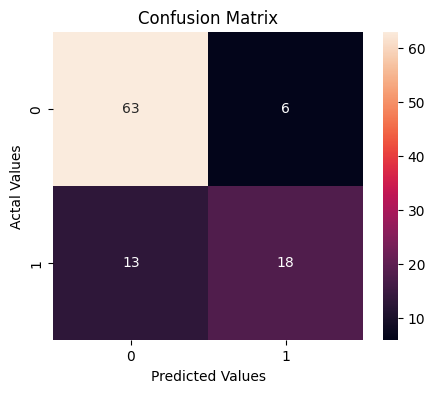

In [21]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True)
plt.title('Confusion Matrix')
plt.ylabel('Actal Values')
plt.xlabel('Predicted Values')
plt.show()

In [4]:
precision_score.__doc__


'Compute the precision.\n\nThe precision is the ratio ``tp / (tp + fp)`` where ``tp`` is the number of\ntrue positives and ``fp`` the number of false positives. The precision is\nintuitively the ability of the classifier not to label as positive a sample\nthat is negative.\n\nThe best value is 1 and the worst value is 0.\n\nSupport beyond term:`binary` targets is achieved by treating :term:`multiclass`\nand :term:`multilabel` data as a collection of binary problems, one for each\nlabel. For the :term:`binary` case, setting `average=\'binary\'` will return\nprecision for `pos_label`. If `average` is not `\'binary\'`, `pos_label` is ignored\nand precision for both classes are computed, then averaged or both returned (when\n`average=None`). Similarly, for :term:`multiclass` and :term:`multilabel` targets,\nprecision for all `labels` are either returned or averaged depending on the\n`average` parameter. Use `labels` specify the set of labels to calculate precision\nfor.\n\nRead more in the

'Accuracy classification score.\n\nIn multilabel classification, this function computes subset accuracy:\nthe set of labels predicted for a sample must *exactly* match the\ncorresponding set of labels in y_true.\n\nRead more in the :ref:`User Guide <accuracy_score>`.\n\nParameters\n----------\ny_true : 1d array-like, or label indicator array / sparse matrix\n    Ground truth (correct) labels.\n\ny_pred : 1d array-like, or label indicator array / sparse matrix\n    Predicted labels, as returned by a classifier.\n\nnormalize : bool, default=True\n    If ``False``, return the number of correctly classified samples.\n    Otherwise, return the fraction of correctly classified samples.\n\nsample_weight : array-like of shape (n_samples,), default=None\n    Sample weights.\n\nReturns\n-------\nscore : float or int\n    If ``normalize == True``, return the fraction of correctly\n    classified samples (float), else returns the number of correctly\n    classified samples (int).\n\n    The best p